## **Image Classification Model - T3 Larger Input Regularized CNN**

### **Purpose**

The purpose of this notebook is to train and evaluate a higher-resolution regularized CNN model for the Lexical Bridge Photo Mission feature. The model classifies uploaded images into one of nine target object classes, such as cat, dog, bird, flower, fruit, vegetable, car, bicycle, and shoe.

This trial builds on the previous BN + Dropout + GAP model. To improve feature learning after the previous model became too constrained, the input image size is increased from 128 × 128 to 224 × 224, the batch size is reduced from 64 to 32, and the number of training epochs is increased from 30 to 100. The augmentation and dropout settings are also relaxed, using random horizontal flipping, smaller random rotation, lighter color jittering, and lower dropout rates. The validation and test sets use fixed preprocessing only, and the checkpoint with the highest validation accuracy is saved for final test evaluation.



### **Structure**
1. Upload and extract the dataset ZIP file
2. Import libraries and set training configuration
3. Prepare image transforms and data loaders with lighter training augmentation
4. Define and summarize the higher-resolution regularized CNN model
5. Set the loss function and optimizer
6. Define training and evaluation functions
7. Train the regularized CNN model for extended epochs
8. Visualize training history
9. Evaluate the best validation checkpoint on the test set
10. Collect test predictions and analyze per-class accuracy
11. Generate the confusion matrix and classification report

## 1. Upload and Extract Dataset ZIP File

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
from pathlib import Path

ZIP_PATH = '/content/drive/MyDrive/LB_dataset.zip'
DATASET_DIR = Path('/content/dataset')

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

shutil.unpack_archive(ZIP_PATH, str(DATASET_DIR))
print('Dataset ZIP file extracted.')

!ls /content/dataset

Mounted at /content/drive
Dataset ZIP file extracted.
test  train  val


## 2. Import Libraries and Set Training Configuration

In [ ]:
!pip install -q torchinfo

In [ ]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Training hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 100
LR = 1e-3
NUM_WORKERS = 0

# ImageNet normalization statistics, commonly used for natural image datasets
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Map detailed classes into broader game categories
CATEGORY_MAP = {
    'cat': 'animal',     'dog': 'animal',     'bird': 'animal',
    'flower': 'nature',  'fruit': 'nature',   'vegetable': 'nature',
    'car': 'daily_life', 'bicycle': 'daily_life', 'shoe': 'daily_life',
}

# Model checkpoint save paths
MODEL_SAVE_PATH = '/content/best_model.pth'
DRIVE_SAVE_PATH = '/content/drive/MyDrive/dyslexiread_best_model.pth'

Device: cuda
GPU: Tesla T4


## 3. Prepare Image Transforms and Data Loaders

In [ ]:
# Basic image transform with data augmentation
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# No data augmentation for the val / test
basic_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
# Load image folders for train, validation, and test sets
train_ds = datasets.ImageFolder(str(DATASET_DIR / 'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(str(DATASET_DIR / 'val'),   transform=basic_tf)
test_ds  = datasets.ImageFolder(str(DATASET_DIR / 'test'),  transform=basic_tf)
CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

# Create data loaders for mini-batch training and evaluation
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

Classes (9): ['bicycle', 'bird', 'car', 'cat', 'dog', 'flower', 'fruit', 'shoe', 'vegetable']
Train: 6219 | Val: 1333 | Test: 1333


## 4. Define CNN Model with Regularization

In [ ]:
class BaselineCNN(nn.Module):
    """
    Improved CNN baseline with regularization techniques

    Architecture
    - Four convolutional blocks: Conv2d -> BatchNorm -> ReLU -> MaxPool
    - Global Average Pooling to reduce FC parameters and prevent overfitting
    - Fully connected classifier with Dropout regularization
    """
    def __init__(self, num_classes=9):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: input channels 3 -> output channels 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),       # Stabilize training and improve generalization
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4: 128 -> 256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # Global Average Pooling reduces each feature map to a single value,
        # significantly reducing the number of parameters in the classifier
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Final classification layers with dropout for regularization
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),                  # Strong dropout before first FC layer
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),                  # Lighter dropout before output layer
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
# Count total and trainable model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
# Display a detailed model summary
summary(
    model,
    input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
)

Total parameters:     423,433
Trainable parameters: 423,433


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BaselineCNN                              [32, 3, 224, 224]         [32, 9]                   --                        True
├─Sequential: 1-1                        [32, 3, 224, 224]         [32, 256, 14, 14]         --                        True
│    └─Conv2d: 2-1                       [32, 3, 224, 224]         [32, 32, 224, 224]        896                       True
│    └─BatchNorm2d: 2-2                  [32, 32, 224, 224]        [32, 32, 224, 224]        64                        True
│    └─ReLU: 2-3                         [32, 32, 224, 224]        [32, 32, 224, 224]        --                        --
│    └─MaxPool2d: 2-4                    [32, 32, 224, 224]        [32, 32, 112, 112]        --                        --
│    └─Conv2d: 2-5                       [32, 32, 112, 112]        [32, 64, 112, 112]        18,496                    True
│    └─

## 5. Set Loss Function and Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)
print('Loss function: CrossEntropyLoss')
print(f'Optimizer: Adam (lr={LR})')

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)


## 6. Define Training and Evaluation Functions

In [ ]:
def train(model, loader, criterion, optimizer, device):
    # Set the model to training mode
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # Forward pass, loss calculation, and parameter update
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # Accumulate loss and accuracy
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    # Set the model to evaluation mode
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            # Forward pass only, without gradient calculation
            outputs = model(images)
            loss = criterion(outputs, labels)
            # Accumulate loss and accuracy
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

## 7. Train the CNN Model

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0

# Train the model for the defined number of epochs
for epoch in range(NUM_EPOCHS):
    # Run one training epoch and evaluate on the validation set
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Store training history for later visualization
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save the model when validation accuracy improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'val_acc': val_acc,
            'class_names': CLASS_NAMES,
        }, MODEL_SAVE_PATH)
    print(
        f'Epoch {epoch + 1:2d}/{NUM_EPOCHS} | '
        f'train loss {train_loss:.4f} acc {train_acc:.4f} | '
        f'val loss {val_loss:.4f} acc {val_acc:.4f}'
    )
print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Epoch  1/100 | train loss 1.8009 acc 0.3173 | val loss 1.6682 acc 0.3863
Epoch  2/100 | train loss 1.6781 acc 0.3624 | val loss 1.5688 acc 0.4336
Epoch  3/100 | train loss 1.6205 acc 0.4017 | val loss 1.6702 acc 0.3653
Epoch  4/100 | train loss 1.5847 acc 0.4136 | val loss 1.4930 acc 0.4494
Epoch  5/100 | train loss 1.5611 acc 0.4231 | val loss 1.4745 acc 0.4606
Epoch  6/100 | train loss 1.5233 acc 0.4395 | val loss 1.5195 acc 0.4306
Epoch  7/100 | train loss 1.5132 acc 0.4401 | val loss 1.4953 acc 0.4801
Epoch  8/100 | train loss 1.4848 acc 0.4522 | val loss 1.3803 acc 0.4966
Epoch  9/100 | train loss 1.4418 acc 0.4671 | val loss 1.4178 acc 0.4764
Epoch 10/100 | train loss 1.4355 acc 0.4634 | val loss 1.4953 acc 0.4561
Epoch 11/100 | train loss 1.4046 acc 0.4787 | val loss 1.4978 acc 0.4674
Epoch 12/100 | train loss 1.4053 acc 0.4854 | val loss 1.3169 acc 0.5274
Epoch 13/100 | train loss 1.3663 acc 0.4936 | val loss 1.5469 acc 0.4329
Epoch 14/100 | train loss 1.3601 acc 0.5033 | val l

## 8. Visualize Training History

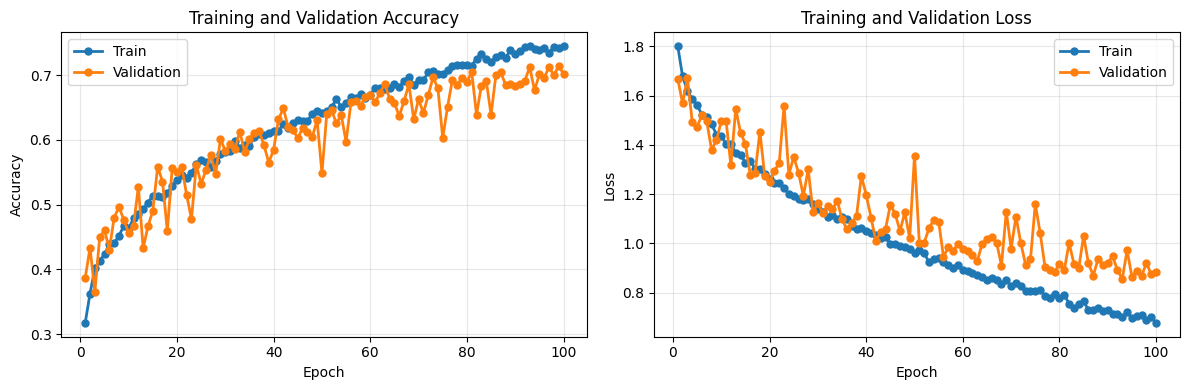

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

# Plot training and validation accuracy
axes[0].plot(epochs_range, history['train_acc'], label='Train', linewidth=2, marker='o', markersize=5)
axes[0].plot(epochs_range, history['val_acc'], label='Validation', linewidth=2, marker='o', markersize=5)
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot training and validation loss
axes[1].plot(epochs_range, history['train_loss'], label='Train', linewidth=2, marker='o', markersize=5)
axes[1].plot(epochs_range, history['val_loss'], label='Validation', linewidth=2, marker='o', markersize=5)
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluate the Best Model on the Test Set

In [ ]:
# Load the best model checkpoint saved during validation
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f'Loaded best model from epoch {checkpoint["epoch"]} (val acc {checkpoint["val_acc"]:.4f})')

# Evaluate the best model on the test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'\nTest loss: {test_loss:.4f}')
print(f'Test accuracy (class-level): {test_acc:.4f}')

Loaded best model from epoch 99 (val acc 0.7142)

Test loss: 0.8920
Test accuracy (class-level): 0.7142


## 10. Analyze Accuracy Per Class

In [ ]:
def collect_predictions(model, loader, device):
    # Set the model to evaluation mode
    model.eval()
    all_preds, all_labels = [], []

    # Collect predicted labels and true labels from the test set
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

# Collect predicted labels and true labels from the test set
y_pred, y_true = collect_predictions(model, test_loader, device)
print('Accuracy per class')

# Calculate accuracy for each class separately
for i, cls in enumerate(CLASS_NAMES):
    mask = y_true == i
    if mask.sum() > 0:
        acc = (y_pred[mask] == i).mean()
        print(f'  {cls:<10s} {acc:.4f}  ({mask.sum()} samples)')

Accuracy per class
  bicycle    0.7800  (150 samples)
  bird       0.6333  (150 samples)
  car        0.8600  (150 samples)
  cat        0.7867  (150 samples)
  dog        0.5267  (150 samples)
  flower     0.8267  (150 samples)
  fruit      0.6667  (150 samples)
  shoe       0.7867  (150 samples)
  vegetable  0.5414  (133 samples)


## 11. Confusion Matrix and Classification Report

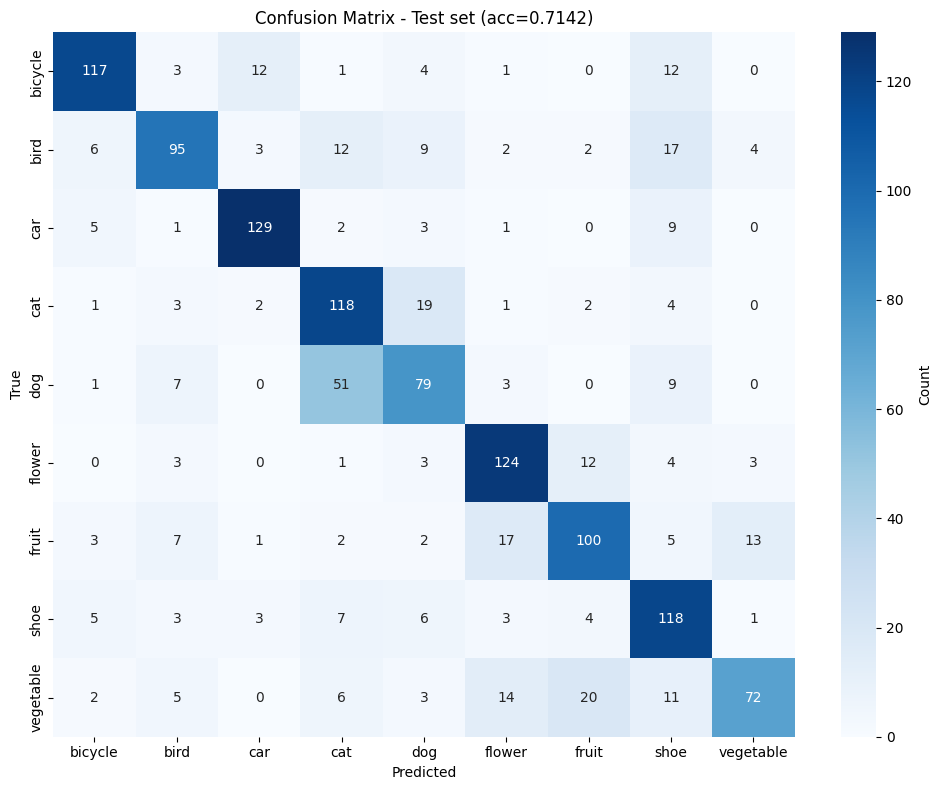


Classification report
              precision    recall  f1-score   support

     bicycle     0.8357    0.7800    0.8069       150
        bird     0.7480    0.6333    0.6859       150
         car     0.8600    0.8600    0.8600       150
         cat     0.5900    0.7867    0.6743       150
         dog     0.6172    0.5267    0.5683       150
      flower     0.7470    0.8267    0.7848       150
       fruit     0.7143    0.6667    0.6897       150
        shoe     0.6243    0.7867    0.6962       150
   vegetable     0.7742    0.5414    0.6372       133

    accuracy                         0.7142      1333
   macro avg     0.7234    0.7120    0.7115      1333
weighted avg     0.7228    0.7142    0.7124      1333



In [ ]:
# Compute the confusion matrix using true and predicted labels
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))

# Visualize how often each true class was predicted as each class
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - Test set (acc={test_acc:.4f})')
plt.tight_layout()
plt.show()

# Print precision, recall, and F1-score for each class
print('\nClassification report')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

In [ ]:
from google.colab import files
files.download(MODEL_SAVE_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>